# 📊 COVID-19 X-Ray Classification using ResNet50

Este notebook implementa un clasificador de rayos X para detectar COVID-19, neumonía viral/bacteriana y casos normales usando Transfer Learning con ResNet50.

## 📦 Datasets requeridos

Los datasets pesados no están incluidos en el repositorio. **Ejecuta las celdas de descarga a continuación** para obtenerlos automáticamente desde Google Drive.

### Archivos necesarios:
- **Dataset/** (imágenes de entrenamiento): ~400 MB
- **Test/** (imágenes de prueba): ~100 MB  
- **weights.weights.h5** (modelo pre-entrenado, opcional): ~90 MB

**Nota**: Si ejecutas en Google Colab, las descargas se harán automáticamente. Para ejecución local, descarga manualmente desde los enlaces en el README.

In [ ]:
# ============================================================================
# 📥 DESCARGA AUTOMÁTICA DE DATASETS DESDE GOOGLE DRIVE
# ============================================================================

import os
import gdown
import zipfile
from pathlib import Path

# ID de la carpeta principal de Google Drive
FOLDER_ID = "1zFAW-VEQ-pXyBZfo9CGEpBjIGe-DJWCn"

print("=" * 70)
print("  📦 CONFIGURACIÓN DE DATASETS - OPERATIONS DEPARTMENT")
print("=" * 70)

# Archivos necesarios
required_files = {
    'Dataset': 'Dataset.zip',
    'Test': 'Test.zip',
    'weights.weights.h5': 'weights.weights.h5'
}

# Verificar archivos existentes
print("\n🔍 Verificando archivos existentes...")
for folder_or_file, _ in required_files.items():
    if os.path.exists(folder_or_file):
        if os.path.isdir(folder_or_file):
            print(f"   ✅ {folder_or_file}/ - Carpeta presente")
        else:
            size_mb = os.path.getsize(folder_or_file) / (1024 * 1024)
            print(f"   ✅ {folder_or_file} - {size_mb:.2f} MB")
    else:
        print(f"   ❌ {folder_or_file} - No encontrado")

# Descargar desde Google Drive si es necesario
if not all(os.path.exists(f) for f in required_files.keys()):
    print("\n📥 Descargando archivos desde Google Drive...")
    print("   Carpeta: DS_APLICADO_NEGOCIOS/4_Operations")
    
    try:
        # Descargar carpeta completa
        gdown.download_folder(
            id=FOLDER_ID,
            quiet=False,
            use_cookies=False
        )
        
        # Extraer archivos ZIP si existen
        for folder, zip_name in required_files.items():
            if zip_name.endswith('.zip') and os.path.exists(zip_name):
                if not os.path.exists(folder):
                    print(f"\n📂 Extrayendo {zip_name}...")
                    with zipfile.ZipFile(zip_name, 'r') as zip_ref:
                        zip_ref.extractall('.')
                    print(f"✅ {folder}/ extraído correctamente")
                    os.remove(zip_name)
                    print(f"🧹 {zip_name} eliminado")
        
        print("\n✅ Descarga completada!")
        
    except Exception as e:
        print(f"\n❌ Error durante la descarga: {e}")
        print("\n⚠️ SOLUCIÓN MANUAL:")
        print(f"   1. Ve a: https://drive.google.com/drive/folders/{FOLDER_ID}")
        print("   2. Descarga los archivos manualmente")
        print("   3. Colócalos en esta carpeta")
else:
    print("\n✅ Todos los archivos ya están presentes")

# Verificación final
print("\n" + "=" * 70)
print("  ? ESTADO FINAL DE ARCHIVOS")
print("=" * 70)
for folder_or_file in required_files.keys():
    if os.path.exists(folder_or_file):
        if os.path.isdir(folder_or_file):
            num_files = len(list(Path(folder_or_file).rglob('*')))
            print(f"   ✅ {folder_or_file}/ - {num_files} archivos")
        else:
            size_mb = os.path.getsize(folder_or_file) / (1024 * 1024)
            print(f"   ✅ {folder_or_file} - {size_mb:.2f} MB")
    else:
        print(f"   ❌ {folder_or_file} - NO ENCONTRADO")

print("\n? Puedes continuar con el resto del notebook.\n")

In [1]:
import os
import cv2
import tensorflow as tf
import numpy as np
from tensorflow.keras import layers, optimizers
from tensorflow.keras.applications.resnet50 import ResNet50
from tensorflow.keras.layers import Input, Add, Dense, Activation, ZeroPadding2D, BatchNormalization, Flatten, Conv2D, AveragePooling2D, MaxPooling2D, Dropout
from tensorflow.keras.models import Model, load_model
from tensorflow.keras import backend as K
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping, ModelCheckpoint, LearningRateScheduler
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd


In [7]:
# Specify training data directory
from pathlib import Path
XRay_Directory = Path.cwd() / '4. Operations Department/Dataset'

In [8]:
# List the folders in the directory
os.listdir(XRay_Directory)

['0', '1', '2', '3']

In [9]:
# Use image generator to generate tensor images data and normalize them
# Use 20% of the data for cross-validation
image_generator = ImageDataGenerator(rescale = 1./255, validation_split= 0.2)

In [10]:
# Generate batches of 40 images
# Total number of images is 133*4 = 532 images
# Training is 428 (80%) and validation is 104 (20%)
# Perform shuffling and image resizing

train_generator = image_generator.flow_from_directory(batch_size = 40, directory= XRay_Directory, shuffle= True, target_size=(256,256), class_mode = 'categorical', subset="training")


Found 428 images belonging to 4 classes.


In [11]:
validation_generator = image_generator.flow_from_directory(batch_size = 40, directory= XRay_Directory, shuffle= True, target_size=(256,256), class_mode = 'categorical', subset="validation")

Found 104 images belonging to 4 classes.


In [12]:
# Generate a batch of 40 images and labels
train_images, train_labels = next(train_generator)


In [13]:
train_images.shape

(40, 256, 256, 3)

In [14]:
train_labels.shape

(40, 4)

In [15]:
train_labels

array([[1., 0., 0., 0.],
       [0., 0., 1., 0.],
       [0., 0., 0., 1.],
       [0., 0., 0., 1.],
       [0., 1., 0., 0.],
       [0., 0., 0., 1.],
       [0., 0., 1., 0.],
       [1., 0., 0., 0.],
       [1., 0., 0., 0.],
       [0., 1., 0., 0.],
       [0., 0., 1., 0.],
       [0., 1., 0., 0.],
       [0., 0., 0., 1.],
       [1., 0., 0., 0.],
       [0., 0., 1., 0.],
       [0., 0., 1., 0.],
       [0., 1., 0., 0.],
       [0., 0., 1., 0.],
       [1., 0., 0., 0.],
       [0., 1., 0., 0.],
       [1., 0., 0., 0.],
       [0., 0., 0., 1.],
       [0., 0., 0., 1.],
       [0., 0., 0., 1.],
       [1., 0., 0., 0.],
       [0., 0., 0., 1.],
       [0., 0., 0., 1.],
       [0., 0., 1., 0.],
       [0., 1., 0., 0.],
       [0., 0., 1., 0.],
       [0., 0., 1., 0.],
       [0., 1., 0., 0.],
       [1., 0., 0., 0.],
       [0., 1., 0., 0.],
       [0., 0., 0., 1.],
       [0., 1., 0., 0.],
       [0., 0., 1., 0.],
       [0., 1., 0., 0.],
       [0., 0., 1., 0.],
       [0., 0., 1., 0.]],

In [16]:
# labels Translator
label_names = {0 : 'Covid-19', 1 : 'Normal' , 2: 'Viral Pneumonia', 3 : 'Bacterial Pneumonia'}

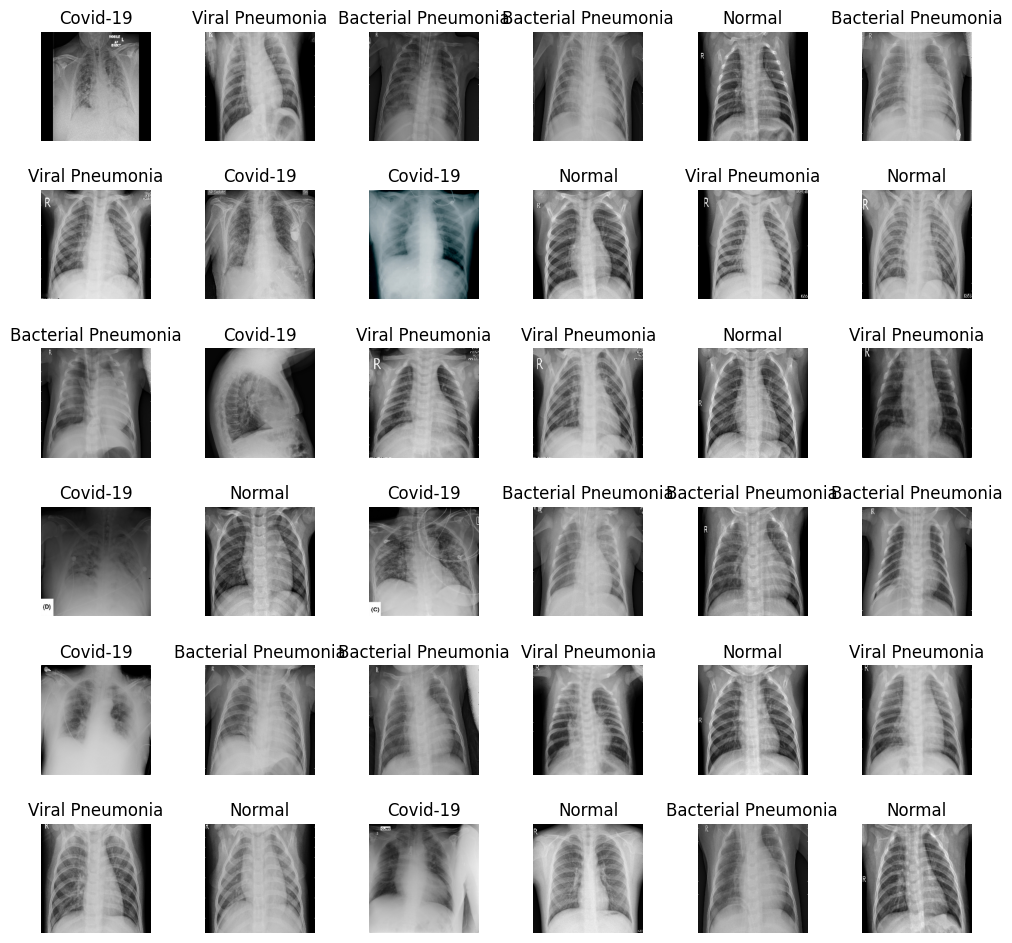

In [17]:
# Create a grid of 36 images along with their corresponding labels
L = 6
W = 6

fig, axes = plt.subplots(L, W, figsize = (12, 12))
axes = axes.ravel()

for i in np.arange(0, L*W):
    axes[i].imshow(train_images[i])
    axes[i].set_title(label_names[np.argmax(train_labels[i])])
    axes[i].axis('off')

plt.subplots_adjust(wspace = 0.5)

In [18]:
basemodel = ResNet50(weights = 'imagenet', include_top = False, input_tensor = Input(shape=(256,256,3)))

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 26s 0us/step


In [19]:
basemodel.summary()

Model: "resnet50"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 262, 262,  │          0 │ input_layer[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 128, 128,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 128, 128,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 128, 128,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 130, 130,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 64, 64,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 64, 64,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 64, 64,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 64, 64,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 64, 64,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 64, 64,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 64, 64,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 64, 64,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 64, 64,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 64, 64,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 64, 64,    │      1,024 │ conv2_block1_3_c

 Total params: 23,587,712 (89.98 MB)

 Trainable params: 23,534,592 (89.78 MB)

 Non-trainable params: 53,120 (207.50 KB)

In [20]:
#freezing the model upto the last stage - 4 and re-training stage -5

for layer in basemodel.layers[:-10]:
  layers.trainable = False

In [21]:
headmodel = basemodel.output
headmodel = AveragePooling2D(pool_size = (4,4))(headmodel)
headmodel = Flatten(name= 'flatten')(headmodel)
headmodel = Dense(256, activation = "relu")(headmodel)
headmodel = Dropout(0.3)(headmodel)
headmodel = Dense(128, activation = "relu")(headmodel)
headmodel = Dropout(0.2)(headmodel)
headmodel = Dense(4, activation = 'softmax')(headmodel)

model = Model(inputs = basemodel.input, outputs = headmodel)

In [23]:
model.compile(loss = 'categorical_crossentropy', optimizer=optimizers.RMSprop(learning_rate=1e-4), metrics=["accuracy"])

In [25]:
# using early stopping to exit training if validation loss is not decreasing even after certain epochs (patience)
earlystopping = EarlyStopping(monitor='val_loss', mode='min', verbose=1, patience=20)

# save the best model with lower validation loss
checkpointer = ModelCheckpoint(filepath="weights.weights.h5", verbose=1, save_best_only=True, save_weights_only=True)

In [26]:
train_generator = image_generator.flow_from_directory(batch_size = 4, directory= XRay_Directory, shuffle= True, target_size=(256,256), class_mode= 'categorical', subset="training")
val_generator = image_generator.flow_from_directory(batch_size = 4, directory= XRay_Directory, shuffle= True, target_size=(256,256), class_mode= 'categorical', subset="validation")

Found 428 images belonging to 4 classes.
Found 104 images belonging to 4 classes.


In [28]:
history = model.fit(train_generator, epochs=10, validation_data=val_generator, callbacks=[checkpointer, earlystopping])

c:\Users\Usuario\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 916ms/step - accuracy: 0.6630 - loss: 0.9602
Epoch 1: val_loss improved from None to 3.48120, saving model to weights.weights.h5
107/107 ━━━━━━━━━━━━━━━━━━━━ 125s 986ms/step - accuracy: 0.7196 - loss: 0.8695 - val_accuracy: 0.2500 - val_loss: 3.4812
Epoch 2/10
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 888ms/step - accuracy: 0.7715 - loss: 0.5491
Epoch 2: val_loss did not improve from 3.48120
107/107 ━━━━━━━━━━━━━━━━━━━━ 100s 932ms/step - accuracy: 0.8248 - loss: 0.4481 - val_accuracy: 0.2500 - val_loss: 16.3087
Epoch 3/10
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 868ms/step - accuracy: 0.9019 - loss: 0.2974
Epoch 3: val_loss did not improve from 3.48120
107/107 ━━━━━━━━━━━━━━━━━━━━ 98s 912ms/step - accuracy: 0.9019 - loss: 0.3559 - val_accuracy: 0.2500 - val_loss: 13.3782
Epoch 4/10
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 868ms/step - accuracy: 0.9415 - loss: 0.2075
Epoch 4: val_loss did not improve from 3.48120
107/107 ━━━━━━━━━━━━━━━━━━━━ 98s 912ms/step - accuracy: 0.9

In [29]:
history.history.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

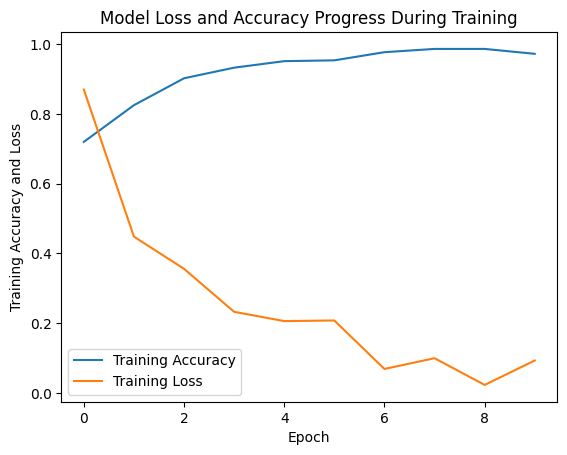

In [30]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['loss'])

plt.title('Model Loss and Accuracy Progress During Training')
plt.xlabel('Epoch')
plt.ylabel('Training Accuracy and Loss')
plt.legend(['Training Accuracy', 'Training Loss'])

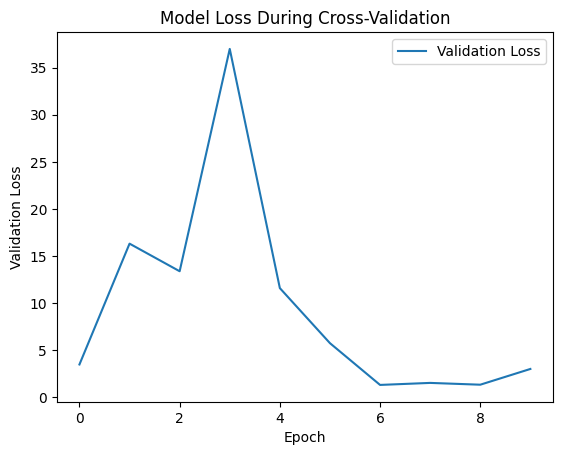

In [31]:
plt.plot(history.history['val_loss'])
plt.title('Model Loss During Cross-Validation')
plt.xlabel('Epoch')
plt.ylabel('Validation Loss')
plt.legend(['Validation Loss'])

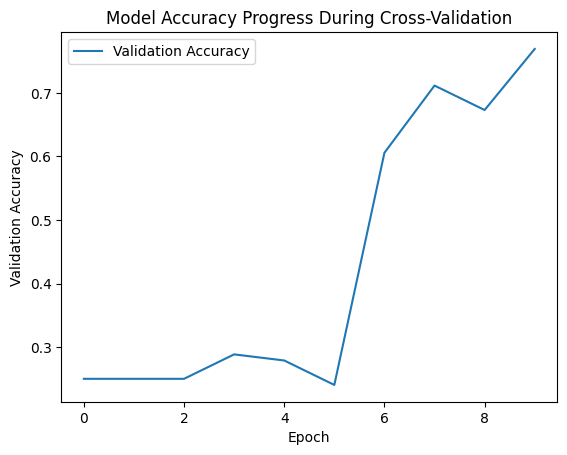

In [32]:
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy Progress During Cross-Validation')
plt.xlabel('Epoch')
plt.ylabel('Validation Accuracy')
plt.legend(['Validation Accuracy'])

In [33]:
from pathlib import Path
test_directory = Path.cwd() / '4. Operations Department/Test'

In [35]:
test_gen = ImageDataGenerator(rescale = 1./255)

test_generator = test_gen.flow_from_directory(batch_size = 40, directory= test_directory, shuffle= True, target_size=(256,256), class_mode= 'categorical')

evaluate = model.evaluate(test_generator, steps=test_generator.n // 4, verbose=1)

print('Accuracy Test : {}'.format(evaluate[1]))

Found 40 images belonging to 4 classes.
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.6750 - loss: 3.8014
Accuracy Test : 0.675000011920929


c:\Users\Usuario\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\trainers\epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


In [36]:
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

prediction = []
original = []
image = []

for i in range(len(os.listdir(test_directory))):
  for item in os.listdir(os.path.join(test_directory,str(i))):
    img= cv2.imread(os.path.join(test_directory,str(i),item))
    img = cv2.resize(img,(256,256))
    image.append(img)
    img = img / 255
    img = img.reshape(-1,256,256,3)
    predict = model.predict(img)
    predict = np.argmax(predict)
    prediction.append(predict)
    original.append(i)

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 126ms/step
1/1 ━━━━

In [37]:
len(original)

40

In [38]:
score = accuracy_score(original,prediction)
print("Test Accuracy : {}".format(score))

Test Accuracy : 0.65


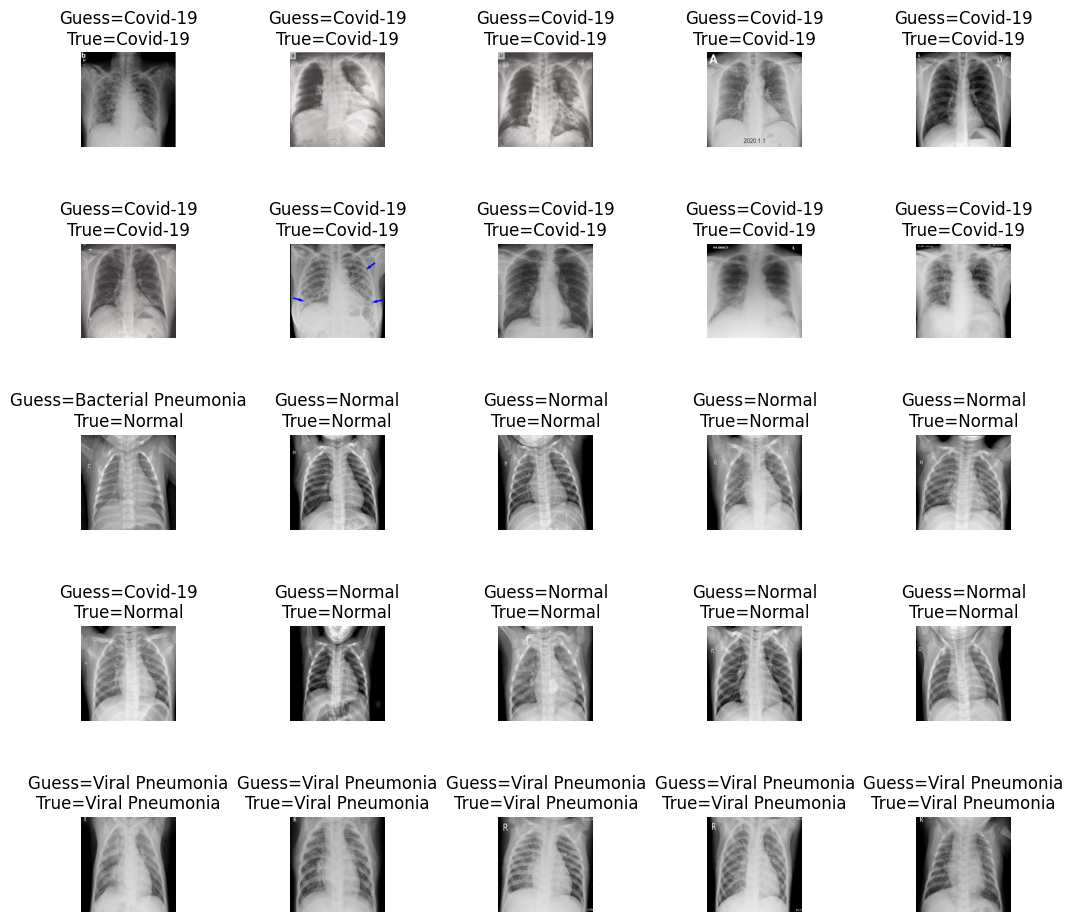

In [39]:
L = 5
W = 5

fig, axes = plt.subplots(L, W, figsize = (12, 12))
axes = axes.ravel()

for i in np.arange(0, L*W):
    axes[i].imshow(image[i])
    axes[i].set_title('Guess={}\nTrue={}'.format(str(label_names[prediction[i]]), str(label_names[original[i]])))
    axes[i].axis('off')

plt.subplots_adjust(wspace = 1.2)

In [40]:
print(classification_report(np.asarray(original), np.asarray(prediction)))

              precision    recall  f1-score   support

           0       0.56      1.00      0.71        10
           1       0.73      0.80      0.76        10
           2       0.83      0.50      0.62        10
           3       0.60      0.30      0.40        10

    accuracy                           0.65        40
   macro avg       0.68      0.65      0.63        40
weighted avg       0.68      0.65      0.63        40



Text(0.5, 1.0, 'Confusion_matrix')

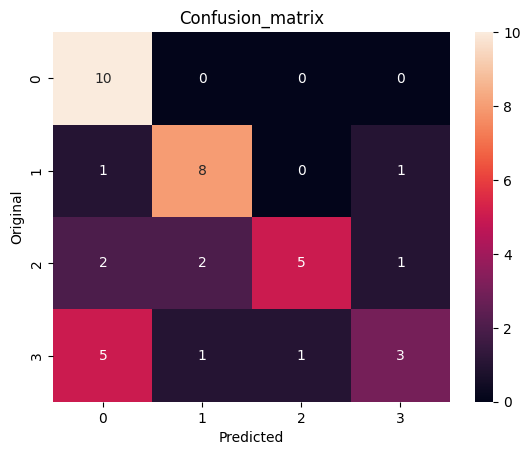

In [41]:
cm = confusion_matrix(np.asarray(original), np.asarray(prediction))
ax = plt.subplot()
sns.heatmap(cm, annot = True, ax = ax)

ax.set_xlabel('Predicted')
ax.set_ylabel('Original')
ax.set_title('Confusion_matrix')